## Continuation probability plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utility.continuation_prob import compute_continuation_probs

### Black-Scholes binomial tree

In [2]:
from black_scholes.tree import BinomialTree
from neural_network.config import MarketParams

In [3]:
n_assets = 1
S0 = 1.0
r = 0.1
sigma = 0.55
K = 1.0
T = 1

params = MarketParams(n_assets, S0, r, sigma, K, T)
american_tree = BinomialTree(params, n_steps=500, exercise_type="american")

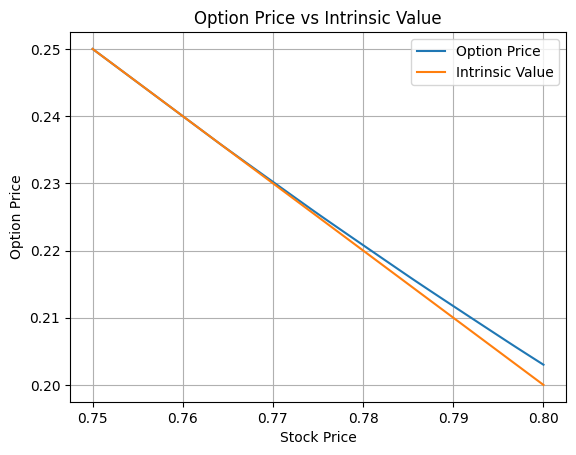

In [10]:
S = np.linspace(0.75, 0.8, 100)
prices = np.array([american_tree.predict(t=0, S=s) for s in S]).flatten()
intrinsics = np.maximum(K - S, 0)

plt.plot(S, prices, label="Option Price")
plt.plot(S, intrinsics, label="Intrinsic Value")
plt.xlabel("Stock Price")
plt.ylabel("Option Price")
plt.title("Option Price vs Intrinsic Value")
plt.legend()
plt.grid()
plt.show()

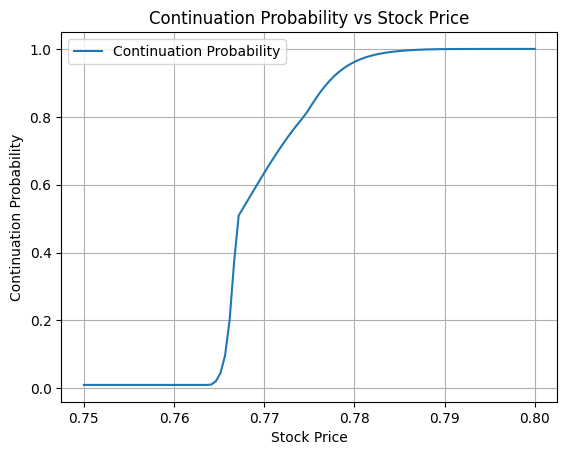

In [16]:
eps1 = 1e-4
eps2 = 1e-3
one = 0.99
shift = -1e-4

cont_probs = compute_continuation_probs(prices, intrinsics, eps1, eps2, one, shift)
plt.plot(S, cont_probs, label="Continuation Probability")
plt.xlabel("Stock Price")
plt.ylabel("Continuation Probability")
plt.title("Continuation Probability vs Stock Price")
plt.legend()
plt.grid()
plt.show()